In [1]:
import os, sys

if os.path.basename(os.getcwd()) == "Jupyters":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
assert os.path.exists("olist.db"), f"olist.db not found in {os.getcwd()} - launch Jupyter from the project root"

import pandas as pd
from IPython.display import Image, display
from src.data_loader import get_connection

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
conn = get_connection()
from src.data_prep import trip_summary
print(trip_summary(conn, gap_hours=1.0))
from src.recommender import *

{'gap_hours': 1.0, 'raw_orders': 96478, 'merged_trips': 95627, 'orders_merged_away': 851, 'repeat_customers_raw': 2801, 'repeat_customers_trips': 2045}


In [3]:
orders = load_orders(conn, merge_gap_hours=1.0)
hist = customer_histories(orders)
print("delivered orders/trips:", len(orders), "| customers:", len(hist),
      "| repeat customers:", sum(len(h) >= 2 for h in hist.values()))

delivered orders/trips: 94297 | customers: 92079 | repeat customers: 2004


## Frequently bought together

In [4]:
fbt_summary, fbt_cases = evaluate_bought_together(orders)
display(fbt_summary.round(3))

,model,n_cases,n_baskets,hit@1,hit@3,hit@5
0,bought_together,1990,982,0.266,0.477,0.575
1,popularity_all_orders,1990,982,0.143,0.236,0.450
2,popularity_multi_cat,1990,982,0.197,0.365,0.466


In [5]:
rows = [compare_to_baseline(fbt_cases, "bought_together", b, "hit@3")
        for b in ["popularity_multi_cat", "popularity_all_orders"]]
display(pd.DataFrame(rows).round(3))

,model,baseline,metric,model_score,baseline_score,abs_diff,rel_lift_pct,ci95_low,ci95_high,verdict
0,bought_together,popularity_multi_cat,hit@3,0.478,0.366,0.112,30.519,0.083,0.139,better than baseline (95% CI excludes 0)
1,bought_together,popularity_all_orders,hit@3,0.478,0.236,0.241,102.010,0.212,0.269,better than baseline (95% CI excludes 0)


## Next order (repeat customers only)
Each repeat customer's last trip is hidden. repeat_last = they will buy the same kind of thing again

In [6]:
next_summary, next_cases = evaluate_next_order(orders)
display(next_summary.round(3))

,model,n_cases,n_customers,hit@1,hit@3,hit@5,recall@1,recall@3,recall@5
0,popularity,2004,2004,0.129,0.304,0.456,0.125,0.298,0.451
1,repeat_last,2004,2004,0.392,0.515,0.619,0.387,0.509,0.614
2,transition,2004,2004,0.382,0.510,0.579,0.377,0.506,0.575
3,hybrid,2004,2004,0.394,0.518,0.584,0.388,0.514,0.579


In [7]:
rows = [compare_to_baseline(next_cases, m, "popularity", "hit@3") for m in ["repeat_last", "transition", "hybrid"]]
rows += [compare_to_baseline(next_cases, m, "repeat_last", "hit@3") for m in ["transition", "hybrid"]]
display(pd.DataFrame(rows).round(3))

,model,baseline,metric,model_score,baseline_score,abs_diff,rel_lift_pct,ci95_low,ci95_high,verdict
0,repeat_last,popularity,hit@3,0.515,0.304,0.211,69.458,0.191,0.232,better than baseline (95% CI excludes 0)
1,transition,popularity,hit@3,0.510,0.304,0.206,67.816,0.180,0.231,better than baseline (95% CI excludes 0)
2,hybrid,popularity,hit@3,0.518,0.304,0.214,70.443,0.188,0.239,better than baseline (95% CI excludes 0)
3,transition,repeat_last,hit@3,0.510,0.515,-0.005,-0.969,-0.021,0.010,not distinguishable from baseline (95% CI incl...
4,hybrid,repeat_last,hit@3,0.518,0.515,0.003,0.581,-0.013,0.017,not distinguishable from baseline (95% CI incl...


## Trying to predict a NEW category
Same test, but categories the customer already bought are excluded from both the recommendations and the truth.

In [8]:
disc_summary, disc_cases = evaluate_next_order(orders, discovery=True)
display(disc_summary.round(3))
display(pd.DataFrame([compare_to_baseline(disc_cases, m, "popularity", "hit@3") for m in ["transition", "hybrid"]]).round(3))

,model,n_cases,n_customers,hit@1,hit@3,hit@5,recall@1,recall@3,recall@5
0,popularity,1214,1214,0.110,0.279,0.444,0.107,0.274,0.439
1,transition,1214,1214,0.115,0.250,0.380,0.112,0.246,0.376
2,hybrid,1214,1214,0.115,0.250,0.380,0.112,0.246,0.376


,model,baseline,metric,model_score,baseline_score,abs_diff,rel_lift_pct,ci95_low,ci95_high,verdict
0,transition,popularity,hit@3,0.25,0.279,-0.03,-10.619,-0.058,-0.003,WORSE than baseline (95% CI excludes 0)
1,hybrid,popularity,hit@3,0.25,0.279,-0.03,-10.619,-0.058,-0.003,WORSE than baseline (95% CI excludes 0)


In [9]:
pop = PopularityRecommender().fit(orders["categories"])
multi = [b for b in orders["categories"] if len(b) >= 2]
fbt = BoughtTogetherRecommender().fit(multi, pop)
print("basket {baby}      ->", fbt.recommend({"baby"}, k=3))
print("basket {perfumery} ->", fbt.recommend({"perfumery"}, k=3))

nxt = NextOrderRecommender().fit([h for h in hist.values() if len(h) >= 2])
example = next(h for h in hist.values() if len(h) >= 2)
print("customer history   ->", [sorted(o) for o in example])
print("next-order top 3   ->", nxt.recommend(example, k=3, strategy="hybrid"))

basket {baby}      -> ['cool_stuff', 'bed_bath_table', 'toys']
basket {perfumery} -> ['health_beauty', 'sports_leisure', 'furniture_decor']
customer history   -> [['cool_stuff'], ['luggage_accessories']]
next-order top 3   -> ['luggage_accessories', 'cool_stuff', 'perfumery']


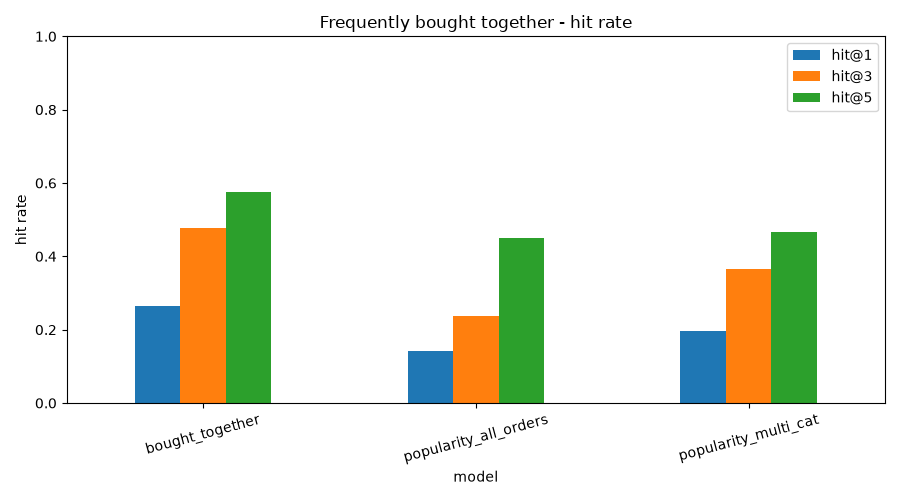

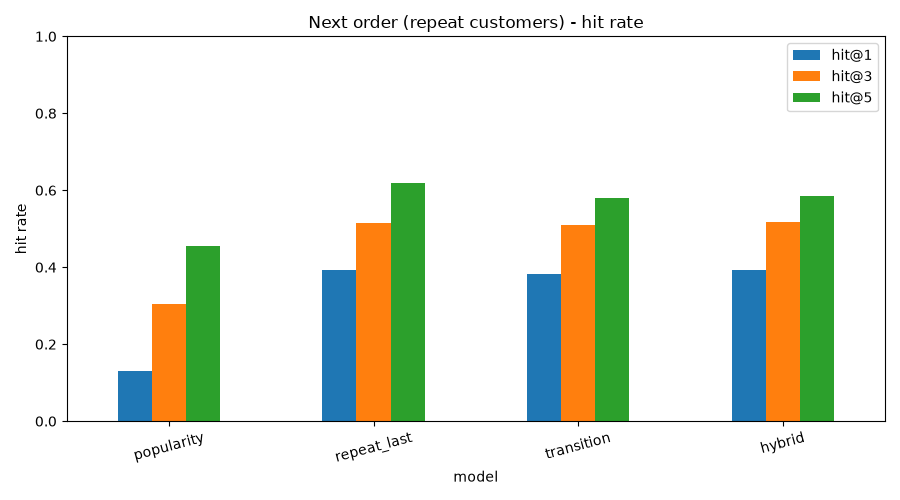

In [10]:
display(Image(save_eval_chart(fbt_summary, "Frequently bought together - hit rate", "eval_fbt.png")))
display(Image(save_eval_chart(next_summary, "Next order (repeat customers) - hit rate", "eval_next_order.png")))